In [67]:
from google.colab import drive
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive', force_remount=True)

base_path = "/content/drive/MyDrive/sequences"
features_path = "/content/drive/MyDrive/features"

Mounted at /content/drive


In [68]:
def load_data_from_path(directory):
    X, y = [], []
    categories = ['normal', 'cheating']

    for label, category in enumerate(categories):
        folder_path = os.path.join(directory, category)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} does not exist.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith('.npy'):
                file_path = os.path.join(folder_path, file)
                # Load sequence data (shape: time_steps, features)
                data = np.load(file_path)
                X.append(data)
                y.append(label)

    return np.array(X), np.array(y)

# Loading all splits from drive
print("Loading Training data...")
X_train, y_train = load_data_from_path(os.path.join(base_path, 'train'))
print("Loading Validation data...")
X_val, y_val = load_data_from_path(os.path.join(base_path, 'val'))
print("Loading Testing data...")
X_test, y_test = load_data_from_path(os.path.join(base_path, 'test'))

print(f"Data loading complete. Training samples: {len(X_train)}")

Loading Training data...
Loading Validation data...
Loading Testing data...
Data loading complete. Training samples: 521


In [69]:
# Compute weights to balance the loss function
unique_classes = np.unique(y_train)
computed_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)
class_weights_dict = dict(zip(unique_classes, computed_weights))

print(f"Class weights calculated: {class_weights_dict}")

Class weights calculated: {np.int64(0): np.float64(2.553921568627451), np.int64(1): np.float64(0.6217183770883055)}


In [72]:
def create_sequence_model(input_shape):
    # Base model for feature extraction from each frame
    base_cnn = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
    base_cnn.trainable = False # Freeze weights to use pre-trained features

    model = Sequential([
        Input(shape=input_shape), # shape: (16, 224, 224, 3)

        # Apply CNN to every frame in the sequence
        tf.keras.layers.TimeDistributed(base_cnn),

        # LSTM layers to process the sequence of features
        LSTM(64, return_sequences=True, dropout=0.3),
        tf.keras.layers.BatchNormalization(),

        LSTM(32, dropout=0.3),

        Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
    )
    return model

# Update input shape to match your data: (Frames, Height, Width, Channels)
# Based on your error, it is (16, 224, 224, 3)
data_input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3], X_train.shape[4])
model = create_sequence_model(data_input_shape)
model.summary()

/tmp/ipykernel_4055/2307444378.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_cnn = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_20             │ (None, 16, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 16, 64)         │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,617,153 (9.98 MB)

 Trainable params: 359,041 (1.37 MB)

 Non-trainable params: 2,258,112 (8.61 MB)

In [73]:
# Define saving path for the best model iteration
checkpoint_path = os.path.join(features_path, "best_cheating_detector.h5")

training_callbacks = [
    # Prevents overfitting by stopping early
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    # Saves the best weights found during training
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True),
    # Adjusts learning rate dynamically
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
]

# Training process
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    class_weight=class_weights_dict,
    callbacks=training_callbacks,
    verbose=1
)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.4342 - loss: 1.1433 - precision: 0.8040 - recall: 0.3975

33/33 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.4472 - loss: 1.1448 - precision: 0.8047 - recall: 0.4129 - val_accuracy: 0.4860 - val_loss: 1.1291 - val_precision: 1.0000 - val_recall: 0.3210 - learning_rate: 1.0000e-04
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.3999 - loss: 1.1322 - precision: 0.7822 - recall: 0.3406

33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 631ms/step - accuracy: 0.4549 - loss: 1.1096 - precision: 0.8462 - recall: 0.3938 - val_accuracy: 0.5327 - val_loss: 1.1103 - val_precision: 1.0000 - val_recall: 0.3827 - learning_rate: 1.0000e-04
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.4473 - loss: 1.1341 - precision: 0.8003 - recall: 0.3903

33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 640ms/step - accuracy: 0.4242 - loss: 1.1067 - precision: 0.8182 - recall: 0.3652 - val_accuracy: 0.4486 - val_loss: 1.1036 - val_precision: 1.0000 - val_recall: 0.2716 - learning_rate: 1.0000e-04
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.5159 - loss: 1.0768 - precision: 0.8962 - recall: 0.4416

33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 565ms/step - accuracy: 0.4818 - loss: 1.0753 - precision: 0.8782 - recall: 0.4129 - val_accuracy: 0.4112 - val_loss: 1.0890 - val_precision: 1.0000 - val_recall: 0.2222 - learning_rate: 1.0000e-04
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.4840 - loss: 1.0446 - precision: 0.8674 - recall: 0.4412

...

33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 567ms/step - accuracy: 0.9060 - loss: 0.4949 - precision: 0.9818 - recall: 0.8998 - val_accuracy: 0.9065 - val_loss: 0.4438 - val_precision: 0.9610 - val_recall: 0.9136 - learning_rate: 1.0000e-04
Epoch 33/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9133 - loss: 0.4779 - precision: 0.9770 - recall: 0.9119

33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 558ms/step - accuracy: 0.9213 - loss: 0.4553 - precision: 0.9846 - recall: 0.9165 - val_accuracy: 0.9252 - val_loss: 0.4288 - val_precision: 0.9506 - val_recall: 0.9506 - learning_rate: 1.0000e-04
Epoch 34/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9417 - loss: 0.4037 - precision: 0.9980 - recall: 0.9296

33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 557ms/step - accuracy: 0.9443 - loss: 0.4137 - precision: 0.9974 - recall: 0.9332 - val_accuracy: 0.9159 - val_loss: 0.4220 - val_precision: 0.9000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 35/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 593ms/step - accuracy: 0.9520 - loss: 0.4059 - precision: 0.9900 - recall: 0.9499 - val_accuracy: 0.9065 - val_loss: 0.4403 - val_precision: 0.9080 - val_recall: 0.9753 - learning_rate: 1.0000e-04
Epoch 36/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9133 - loss: 0.4511 - precision: 0.9861 - recall: 0.9050

33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 563ms/step - accuracy: 0.9251 - loss: 0.4266 - precision: 0.9922 - recall: 0.9141 - val_accuracy: 0.9159 - val_loss: 0.4213 - val_precision: 0.9615 - val_recall: 0.9259 - learning_rate: 1.0000e-04
Epoch 37/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9540 - loss: 0.3902 - precision: 0.9973 - recall: 0.9442

33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 559ms/step - accuracy: 0.9520 - loss: 0.3959 - precision: 0.9975 - recall: 0.9427 - val_accuracy: 0.9159 - val_loss: 0.4167 - val_precision: 0.9500 - val_recall: 0.9383 - learning_rate: 1.0000e-04
Epoch 38/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 524ms/step - accuracy: 0.9693 - loss: 0.3802 - precision: 0.9975 - recall: 0.9642 - val_accuracy: 0.8879 - val_loss: 0.4652 - val_precision: 0.8966 - val_recall: 0.9630 - learning_rate: 1.0000e-04
Epoch 39/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 523ms/step - accuracy: 0.9559 - loss: 0.3653 - precision: 0.9975 - recall: 0.9475 - val_accuracy: 0.9065 - val_loss: 0.4826 - val_precision: 0.8989 - val_recall: 0.9877 - learning_rate: 1.0000e-04
Epoch 40/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 520ms/step - accuracy: 0.9635 - loss: 0.3602 - precision: 0.9950 - recall: 0.9594 - val_accuracy: 0.9065 - val_loss: 0.5340 - val_precision: 0.8901 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 41/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 520ms

Test Accuracy: 0.8917


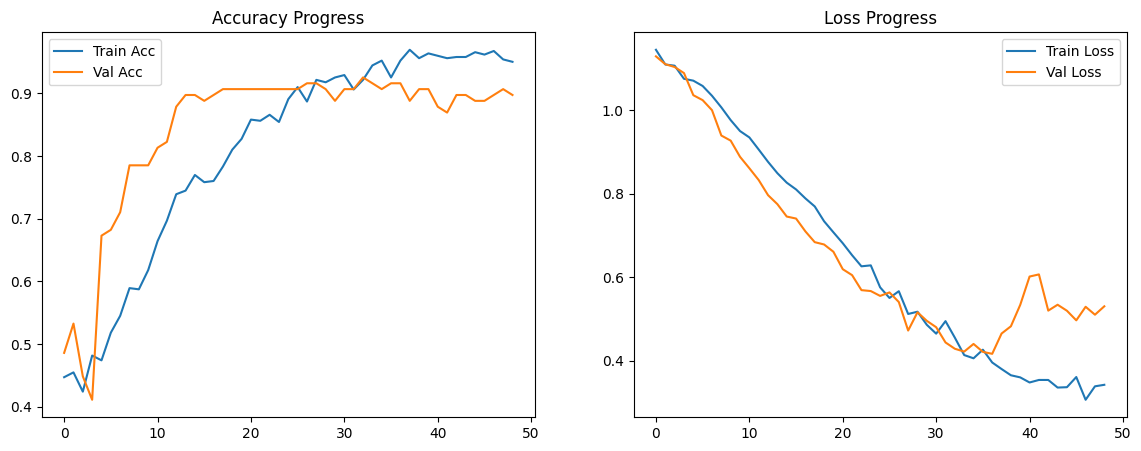

4/4 ━━━━━━━━━━━━━━━━━━━━ 42s 7s/step


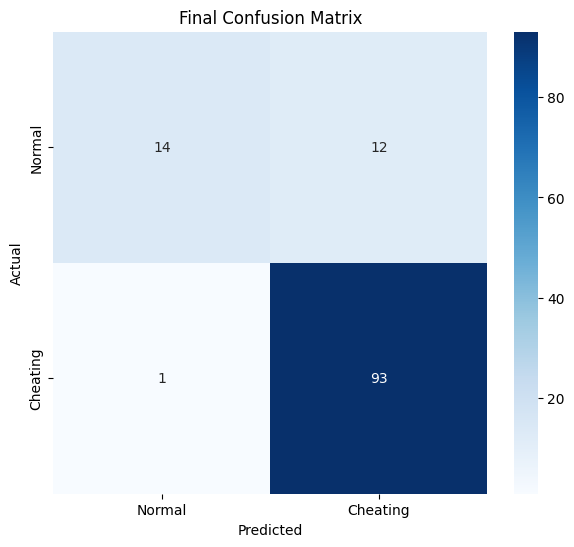

Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.54      0.68        26
    Cheating       0.89      0.99      0.93        94

    accuracy                           0.89       120
   macro avg       0.91      0.76      0.81       120
weighted avg       0.90      0.89      0.88       120



In [74]:
# Evaluate model performance on unseen test data
results = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {results[1]:.4f}")

# Plotting Accuracy and Loss curves
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Progress')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Progress')
plt.legend()
plt.show()

# Generate Confusion Matrix
predictions = (model.predict(X_test) > 0.5).astype("int32")
conf_matrix = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Cheating'], yticklabels=['Normal', 'Cheating'])
plt.title('Final Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Final classification report
print("Classification Report:")
print(classification_report(y_test, predictions, target_names=['Normal', 'Cheating']))